# Elfving 2010 composite preset demo

This notebook demonstrates a reusable simulation-context preset for a composite stand workflow:

1. Regeneration quality via the published Elfving regeneration functions (Appendix 2; ASINW).
2. Stand creation via NYSKOG.
3. Young-stand growth via Nyström (2000 + Nyström/Söderberg 1987) with Näslund (1986) damage index and damage mortality.
4. Mortality routing via the Swedish mortality engine each 5-year step.
5. Smoothed phase-over from young to mature growth and mature-tree forecasting with Elfving 2010 stand-level correction.
6. Standing valuation each 5-year step with Söderberg (1992) bark/height and Mellanskog 2013 prices.


## Handover logic (pyforestry preset)
In `Elfving2010Pipeline.step()` the handover is handled as a smooth hybrid, not a hard plot-type switch:

1. Trees with `dbh_cm < handover_dbh_cm` are treated as young-phase trees and updated with Nyström-based young-stand growth (`_apply_nystrom_young_growth`).
2. The Elfving 2010 mature-tree step is then run through the simulation context (`_ctx.update_step(dt)`).
3. For trees that were young at step start, DBH is blended between young and mature trajectories using
   `phase_over_weight = sigmoid((mean_height - handover_mean_height_m) / handover_smoothing_width_m)`.
4. As stand mean height rises, `phase_over_weight` moves from ~0 to ~1, so influence shifts progressively from young-stand equations to mature-tree equations.

`handover_dbh_cm` remains the tree-level split helper, while `handover_mean_height_m` + `handover_smoothing_width_m` control how quickly the stand-level transition occurs.



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from pyforestry.base.helpers.primitives import SiteBase
from pyforestry.sweden.simulation.presets import (
    Elfving2010Pipeline,
    Elfving2010PipelineConfig,
    build_elfving_2010_pipeline,
)
from pyforestry.sweden.site import Sweden, SwedishSite
from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1977 import Hagglund_Lundmark_1977_SIS


In [2]:
class SwedishSiteDemo(SwedishSite):
    """Concrete wrapper for notebooks (implements SiteBase abstract method)."""

    def compute_attributes(self) -> None:
        SwedishSite.__post_init__(self)

    def __post_init__(self) -> None:
        SiteBase.__post_init__(self)


In [3]:
site_index_pine_m = 20.0
site_index_spruce_m = 22.0
county = Sweden.County.KOPPARBERG_OVRIGA
site_category_species = "Pinus sylvestris"
requested_sis = site_index_pine_m

predicted_site_categories = predict_site_categories_county_tree(
    sis_hagglund_1979=requested_sis,
    species=site_category_species,
    Direktlan=county,
)

site = SwedishSiteDemo(
    latitude=60.5,
    longitude=15.0,
    altitude=150.0,
    field_layer=predicted_site_categories["field_layer"],
    bottom_layer=predicted_site_categories["bottom_layer"],
    soil_texture=predicted_site_categories["soil_texture"],
    soil_moisture=predicted_site_categories["soil_moisture"],
    soil_depth=predicted_site_categories["soil_depth"],
    soil_water=predicted_site_categories["soil_water"],
    ditched=predicted_site_categories["ditched"],
)

achieved_sis = Hagglund_Lundmark_1977_SIS(
    species=site_category_species,
    latitude=site.latitude,
    altitude=site.altitude or 0.0,
    soil_moisture=site.soil_moisture,
    ground_layer=site.bottom_layer or Sweden.BottomLayer.FRESH_MOSS,
    vegetation=site.field_layer,
    soil_texture=site.soil_texture or Sweden.SoilTextureTill.SANDY,
    climate_code=site.climate_zone or Sweden.ClimateZone.K1,
    lateral_water=site.soil_water or Sweden.SoilWater.SELDOM_NEVER,
    soil_depth=site.soil_depth or Sweden.SoilDepth.DEEP,
    incline_percent=site.incline_percent or 0.0,
    aspect=site.aspect or 0.0,
    nfi_adjustments=True,
    dlan=site.county or county,
    ditched=bool(site.ditched),
    peat=False,
    gotland=False,
    coast=(site.distance_to_coast or 9999.0) < 50.0,
    limes_norrlandicus=bool(site.n_of_limes_norrlandicus),
)

sis_closeness = {
    "requested_sis": requested_sis,
    "achieved_sis": float(achieved_sis),
    "sis_abs_error": abs(float(achieved_sis) - requested_sis),
    "sis_rel_error_pct": 100.0 * abs(float(achieved_sis) - requested_sis) / requested_sis,
}

display({"sis_closeness": sis_closeness, "predicted_site_categories": predicted_site_categories})

cube_path = Path("/tmp/pyforestry_elfving_2010_valuation_cube.nc")

config = Elfving2010PipelineConfig(
    site_index_pine_m=site_index_pine_m,
    site_index_spruce_m=site_index_spruce_m,
    initial_age_years=12.0,
    sample_trees=80,
    random_seed=42,
    dt_years=5.0,
    handover_dbh_cm=10.0,
    handover_mean_height_m=7.0,
    handover_smoothing_width_m=1.0,
    valuation_solution_cube_path=str(cube_path),
    valuation_solution_cube_autogenerate_if_missing=True,
    valuation_solution_cube_generate_workers=2,
)

preset = build_elfving_2010_pipeline(config)

# Builds the cube on first run, then reuses the cached file.
preset.ensure_valuation_solution_cube(
    path=str(cube_path),
    workers=config.valuation_solution_cube_generate_workers,
)
preset

{'sis_closeness': {'requested_sis': 20.0,
  'achieved_sis': 20.698654683125625,
  'sis_abs_error': 0.6986546831256248,
  'sis_rel_error_pct': 3.493273415628124},
 'predicted_site_categories': {'field_layer': <SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>,
  'bottom_layer': <SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>,
  'soil_texture': <SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>,
  'soil_moisture': <SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>,
  'soil_depth': <SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcro

Generating Solution Cube using 2 parallel processes...
Pricelist hash: 4058af6a860784c4a6ce94f561a4f484a0401624c2f3cc8405c3074570164174
Total trees to process: 168


Generating Solution Cube:   0%|          | 0/168 [00:00<?, ?it/s]

Generating Solution Cube:   1%|          | 1/168 [00:02<08:08,  2.93s/it]

Generating Solution Cube:   7%|▋         | 11/168 [00:03<00:33,  4.63it/s]

...

Generating Solution Cube:  84%|████████▍ | 141/168 [00:27<00:05,  5.35it/s]

Generating Solution Cube:  90%|████████▉ | 151/168 [00:28<00:02,  5.74it/s]

Generating Solution Cube:  96%|█████████▌| 161/168 [00:30<00:01,  5.61it/s]

Generating Solution Cube: 100%|██████████| 168/168 [00:30<00:00,  5.48it/s]


Finished parallel computation in 30.82 seconds.
Successfully created xarray Dataset.
Saving solution cube to /tmp/pyforestry_elfving_2010_valuation_cube.nc...
Save complete.
Loading solution cube from /tmp/pyforestry_elfving_2010_valuation_cube.nc...
Pricelist hash verified.
Cube loaded successfully.


In [4]:
results = preset.run_projection(site=site, n_steps=30)
results


/home/runner/work/pyforestry/pyforestry/src/pyforestry/sweden/simulation/mortality/engine.py:452: UserWarning: Soderberg self-thinning annual probability exceeded [0, 1]; clamped.
  probabilities, adjusted, factors, diag = calibrate_soderberg(


Loading solution cube from /tmp/pyforestry_elfving_2010_valuation_cube.nc...
Pricelist hash verified.
Cube loaded successfully.


,step_index,age_years,years_elapsed,stems_per_ha,mean_dbh_cm,mean_height_m,qmd_cm,hq_m,basal_area_m2_ha,standing_volume_m3sk_per_ha,...,birch_ba_share,handover_dbh_cm,handover_mean_height_m,handover_smoothing_width_m,phase_over_weight,young_damage_index_mean,young_damage_mortality_stems_removed_per_ha,mortality_fraction_mean,mortality_stems_removed_per_ha,young_stand_potential_q
0,0.0,12.0,0.0,6244.836223,1.160088,1.918334,1.717078,2.842679,1.446076,4.496444,...,0.280345,10.0,7.0,1.0,0.020369,0.000000,0.000000,0.000000,0.000000,77.405649
1,1.0,17.0,5.0,5908.674359,3.723783,3.101748,4.805095,4.353365,10.714795,33.963809,...,0.399829,10.0,7.0,1.0,0.026043,0.332107,336.161863,0.000000,0.000000,77.405649
2,2.0,22.0,10.0,5550.689031,5.248992,4.522355,6.714606,6.124363,19.655217,80.164338,...,0.357841,10.0,7.0,1.0,0.089333,0.304633,267.431934,0.025557,90.553394,77.405649
3,3.0,27.0,15.0,5155.787371,6.176141,5.668342,7.920347,7.906953,25.402312,125.554411,...,0.350014,10.0,7.0,1.0,0.252886,0.285739,230.941659,0.049156,163.960002,77.405649
4,4.0,32.0,20.0,4771.097075,6.911576,6.123854,8.886608,9.230598,29.592402,155.809700,...,0.333385,10.0,7.0,1.0,0.425136,0.290409,198.591669,0.060045,186.098627,77.405649
5,5.0,37.0,25.0,4382.269859,7.540848,6.778780,9.614655,11.067369,31.816795,179.806209,...,0.326846,10.0,7.0,1.0,0.397661,0.505103,198.380126,0.066713,190.447090,77.405649
6,6.0,42.0,30.0,4016.926255,8.153873,7.383881,10.313617,12.673264,33.558750,200.999074,...,0.320099,10.0,7.0,1.0,0.563326,0.517898,180.756170,0.070496,184.587433,77.405649
7,7.0,47.0,35.0,3679.230739,8.761359,7.953915,10.995712,13.005644,34.937647,219.777138,...,0.313630,10.0,7.0,1.0,0.705125,0.531285,163.332790,0.072910,174.362726,77.405649
8,8.0,52.0,40.0,3370.231445,9.369156,8.497383,11.668168,13.291059,36.037526,236.467046,...,0.307575,10.0,7.0,1.0,0.810059,0.545287,146.413942,0.074574,162.585352,77.405649
9,9.0,57.0,45.0,3089.434197,9.979890,9.018861,12.335058,13.719830,36.919113,251.337857,...,0.301817,10.0,7.0,1.0,0.880636,0.559934,130.243720,0.075759,150.553528,77.405649


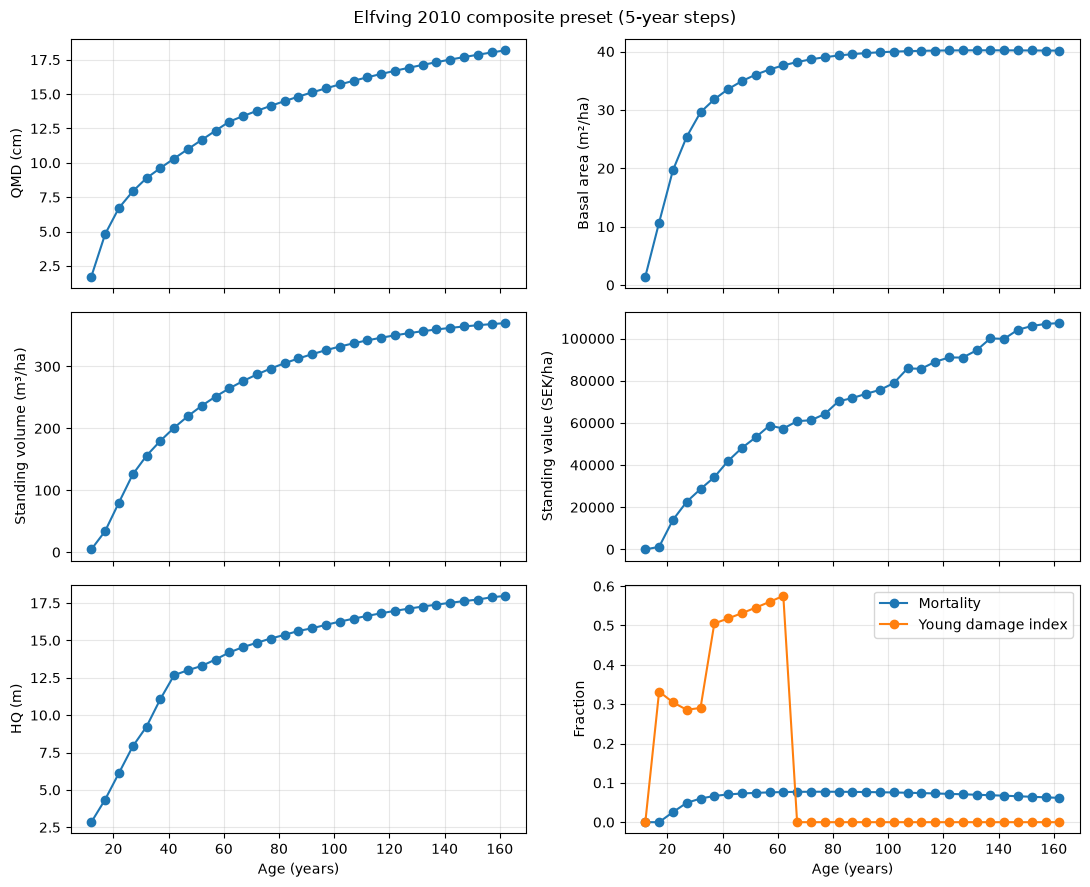

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

axes[0].plot(results["age_years"], results["qmd_cm"], marker="o")
axes[0].set_ylabel("QMD (cm)")

axes[1].plot(results["age_years"], results["basal_area_m2_ha"], marker="o")
axes[1].set_ylabel("Basal area (m²/ha)")

axes[2].plot(results["age_years"], results["standing_volume_m3sk_per_ha"], marker="o")
axes[2].set_ylabel("Standing volume (m³/ha)")

axes[3].plot(results["age_years"], results["standing_value_sek_per_ha"], marker="o")
axes[3].set_ylabel("Standing value (SEK/ha)")

axes[4].plot(results["age_years"], results["hq_m"], marker="o")
axes[4].set_ylabel("HQ (m)")
axes[4].set_xlabel("Age (years)")

axes[5].plot(
    results["age_years"],
    results["mortality_fraction_mean"],
    marker="o",
    label="Mortality",
)
axes[5].plot(
    results["age_years"],
    results["young_damage_index_mean"],
    marker="o",
    label="Young damage index",
)
axes[5].set_ylabel("Fraction")
axes[5].set_xlabel("Age (years)")
axes[5].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Elfving 2010 composite preset (5-year steps)", fontsize=12)
fig.tight_layout()


In [6]:
results[[
    "step_index",
    "age_years",
    "stems_per_ha",
    "qmd_cm",
    "hq_m",
    "phase_over_weight",
    "young_damage_index_mean",
    "mortality_fraction_mean",
    "standing_volume_m3sk_per_ha",
    "standing_value_sek_per_ha",
]]

,step_index,age_years,stems_per_ha,qmd_cm,hq_m,phase_over_weight,young_damage_index_mean,mortality_fraction_mean,standing_volume_m3sk_per_ha,standing_value_sek_per_ha
0,0.0,12.0,6244.836223,1.717078,2.842679,0.020369,0.000000,0.000000,4.496444,0.000000
1,1.0,17.0,5908.674359,4.805095,4.353365,0.026043,0.332107,0.000000,33.963809,1211.826847
2,2.0,22.0,5550.689031,6.714606,6.124363,0.089333,0.304633,0.025557,80.164338,13981.675844
3,3.0,27.0,5155.787371,7.920347,7.906953,0.252886,0.285739,0.049156,125.554411,22603.566895
4,4.0,32.0,4771.097075,8.886608,9.230598,0.425136,0.290409,0.060045,155.809700,28614.249245
5,5.0,37.0,4382.269859,9.614655,11.067369,0.397661,0.505103,0.066713,179.806209,34250.517477
6,6.0,42.0,4016.926255,10.313617,12.673264,0.563326,0.517898,0.070496,200.999074,41959.996125
7,7.0,47.0,3679.230739,10.995712,13.005644,0.705125,0.531285,0.072910,219.777138,48124.991824
8,8.0,52.0,3370.231445,11.668168,13.291059,0.810059,0.545287,0.074574,236.467046,53137.994952
9,9.0,57.0,3089.434197,12.335058,13.719830,0.880636,0.559934,0.075759,251.337857,58736.571923


## Genetic algorithm: best thinning routine (perpetuity objective)

This section uses a genetic algorithm (GA) to find a thinning routine that maximizes a **perpetuity** objective (NPV/EAV/LEV), while still simulating multiple generations for robust trajectory behavior.

Assumptions:
- `0-4` thinnings per generation (from below, by basal-area fraction).
- Mandatory clear-cut at the end of each rotation.
- Replant/regenerate by calling `preset.initialize(site=site)` exactly as at stand instantiation.
- No site-index or productivity drift over time (`config` unchanged, deterministic seed).


In [7]:
import copy
import io
import math
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout

import numpy as np
import pandas as pd
from joblib import Parallel, delayed

warnings.filterwarnings(
    "ignore",
    message="Soderberg self-thinning annual probability exceeded .*",
)

GA_ROTATION_YEARS = 70
GA_NUM_GENERATIONS = 4
GA_DISCOUNT_RATE = 0.03
GA_MAX_THINNINGS = 4
GA_REGENERATION_COST_SEK_PER_HA = 0.0

GA_DT_YEARS = float(config.dt_years)
GA_AGE_MIN = GA_DT_YEARS
GA_AGE_MAX = GA_ROTATION_YEARS - GA_DT_YEARS
GA_INTENSITY_MIN = 0.10
GA_INTENSITY_MAX = 0.50
GA_GRADE_MIN = -1.0
GA_GRADE_MAX = 1.0
GA_SPECIES_WEIGHT_MIN = 0.25
GA_SPECIES_WEIGHT_MAX = 3.0
GA_REGEN_YEARS = float(max(0.0, config.initial_age_years))

if abs((GA_ROTATION_YEARS / GA_DT_YEARS) - round(GA_ROTATION_YEARS / GA_DT_YEARS)) > 1e-9:
    raise ValueError("GA_ROTATION_YEARS must be divisible by config.dt_years")


def ga_quiet_call(func, /, *args, **kwargs):
    with io.StringIO() as stdout_buffer, io.StringIO() as stderr_buffer:
        with redirect_stdout(stdout_buffer), redirect_stderr(stderr_buffer):
            return func(*args, **kwargs)


def ga_tree_basal_area_m2_ha(tree) -> float:
    d_cm = float(tree.diameter_cm or 0.0)
    w = float(tree.weight_n or 0.0)
    if d_cm <= 0.0 or w <= 0.0:
        return 0.0
    return math.pi * (d_cm / 200.0) ** 2 * w


def ga_species_group(tree) -> str:
    species = getattr(tree, "species", None)
    full_name = str(getattr(species, "full_name", "") or "").lower()
    if "picea" in full_name:
        return "spruce"
    if "pinus" in full_name or "larix" in full_name:
        return "pine"
    return "broadleaf"


def ga_parse_thinning_decision(decision) -> dict[str, float]:
    if isinstance(decision, (float, int)):
        return {
            "intensity": float(np.clip(float(decision), GA_INTENSITY_MIN, GA_INTENSITY_MAX)),
            "grade": -1.0,
            "spruce_weight": 1.0,
            "pine_weight": 1.0,
            "broadleaf_weight": 1.0,
        }

    if len(decision) == 2:
        _age_year, intensity = decision
        return {
            "intensity": float(np.clip(float(intensity), GA_INTENSITY_MIN, GA_INTENSITY_MAX)),
            "grade": -1.0,
            "spruce_weight": 1.0,
            "pine_weight": 1.0,
            "broadleaf_weight": 1.0,
        }

    if len(decision) != 6:
        raise ValueError("Thinning decision must be float/int, (age, intensity), or 6-tuple")

    _age_year, intensity, grade, w_spruce, w_pine, w_broadleaf = decision
    return {
        "intensity": float(np.clip(float(intensity), GA_INTENSITY_MIN, GA_INTENSITY_MAX)),
        "grade": float(np.clip(float(grade), GA_GRADE_MIN, GA_GRADE_MAX)),
        "spruce_weight": float(
            np.clip(float(w_spruce), GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)
        ),
        "pine_weight": float(np.clip(float(w_pine), GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)),
        "broadleaf_weight": float(
            np.clip(float(w_broadleaf), GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)
        ),
    }


def ga_apply_targeted_thinning(preset, thinning_decision) -> dict[str, float]:
    decision = ga_parse_thinning_decision(thinning_decision)
    frac = float(np.clip(decision["intensity"], 0.0, 0.95))

    if frac <= 0.0:
        return {
            "harvest_value_sek_per_ha": 0.0,
            "harvest_volume_m3_per_ha": 0.0,
            "removed_stems_per_ha": 0.0,
            "removed_basal_area_m2_ha": 0.0,
            "removed_spruce_stems_per_ha": 0.0,
            "removed_pine_stems_per_ha": 0.0,
            "removed_broadleaf_stems_per_ha": 0.0,
            "thinning_grade": float(decision["grade"]),
            "spruce_weight": float(decision["spruce_weight"]),
            "pine_weight": float(decision["pine_weight"]),
            "broadleaf_weight": float(decision["broadleaf_weight"]),
        }

    candidates = [
        t
        for t in preset.tree_list
        if float(t.weight_n or 0.0) > 0.0 and float(t.diameter_cm or 0.0) > 0.0
    ]
    if not candidates:
        return {
            "harvest_value_sek_per_ha": 0.0,
            "harvest_volume_m3_per_ha": 0.0,
            "removed_stems_per_ha": 0.0,
            "removed_basal_area_m2_ha": 0.0,
            "removed_spruce_stems_per_ha": 0.0,
            "removed_pine_stems_per_ha": 0.0,
            "removed_broadleaf_stems_per_ha": 0.0,
            "thinning_grade": float(decision["grade"]),
            "spruce_weight": float(decision["spruce_weight"]),
            "pine_weight": float(decision["pine_weight"]),
            "broadleaf_weight": float(decision["broadleaf_weight"]),
        }

    total_ba = sum(ga_tree_basal_area_m2_ha(t) for t in candidates)
    target_ba = total_ba * frac
    if target_ba <= 1e-12:
        return {
            "harvest_value_sek_per_ha": 0.0,
            "harvest_volume_m3_per_ha": 0.0,
            "removed_stems_per_ha": 0.0,
            "removed_basal_area_m2_ha": 0.0,
            "removed_spruce_stems_per_ha": 0.0,
            "removed_pine_stems_per_ha": 0.0,
            "removed_broadleaf_stems_per_ha": 0.0,
            "thinning_grade": float(decision["grade"]),
            "spruce_weight": float(decision["spruce_weight"]),
            "pine_weight": float(decision["pine_weight"]),
            "broadleaf_weight": float(decision["broadleaf_weight"]),
        }

    dbh_vals = np.array([float(t.diameter_cm or 0.0) for t in candidates], dtype=float)
    dbh_min = float(np.min(dbh_vals))
    dbh_max = float(np.max(dbh_vals))
    dbh_span = max(1e-6, dbh_max - dbh_min)
    grade = float(decision["grade"])
    alpha = (grade + 1.0) / 2.0  # -1 => 0 (from below), +1 => 1 (from above)

    species_weights = {
        "spruce": float(decision["spruce_weight"]),
        "pine": float(decision["pine_weight"]),
        "broadleaf": float(decision["broadleaf_weight"]),
    }

    scored_candidates: list[tuple[float, object]] = []
    for tree in candidates:
        dbh = float(tree.diameter_cm or 0.0)
        dbh_norm = float((dbh - dbh_min) / dbh_span)
        dbh_priority = (1.0 - alpha) * (1.0 - dbh_norm) + alpha * dbh_norm
        sp_group = ga_species_group(tree)
        sp_weight = species_weights[sp_group]
        priority = sp_weight * (0.5 + dbh_priority)
        scored_candidates.append((priority, tree))

    scored_candidates.sort(key=lambda item: (item[0], float(item[1].diameter_cm or 0.0)), reverse=True)

    removed_records = []
    removed_ba = 0.0
    removed_stems = 0.0
    removed_species_stems = {"spruce": 0.0, "pine": 0.0, "broadleaf": 0.0}

    for _priority, tree in scored_candidates:
        if removed_ba >= target_ba - 1e-12:
            break

        tree_ba = ga_tree_basal_area_m2_ha(tree)
        weight = float(tree.weight_n or 0.0)
        if tree_ba <= 0.0 or weight <= 0.0:
            continue

        take_ratio = min(1.0, (target_ba - removed_ba) / tree_ba)
        take_weight = weight * take_ratio
        if take_weight <= 0.0:
            continue

        removed_tree = copy.copy(tree)
        removed_tree.weight_n = take_weight
        removed_records.append(removed_tree)

        tree.weight_n = weight - take_weight
        removed_stems += take_weight
        removed_ba += tree_ba * take_ratio
        removed_species_stems[ga_species_group(tree)] += take_weight

    preset._trees = [t for t in preset.tree_list if float(t.weight_n or 0.0) > 1e-9]

    harvest = preset.value_standing_forest(removed_records) if removed_records else {
        "standing_value_sek_per_ha": 0.0,
        "standing_volume_m3sk_per_ha": 0.0,
    }
    return {
        "harvest_value_sek_per_ha": float(harvest["standing_value_sek_per_ha"]),
        "harvest_volume_m3_per_ha": float(harvest["standing_volume_m3sk_per_ha"]),
        "removed_stems_per_ha": float(removed_stems),
        "removed_basal_area_m2_ha": float(removed_ba),
        "removed_spruce_stems_per_ha": float(removed_species_stems["spruce"]),
        "removed_pine_stems_per_ha": float(removed_species_stems["pine"]),
        "removed_broadleaf_stems_per_ha": float(removed_species_stems["broadleaf"]),
        "thinning_grade": float(grade),
        "spruce_weight": float(species_weights["spruce"]),
        "pine_weight": float(species_weights["pine"]),
        "broadleaf_weight": float(species_weights["broadleaf"]),
    }


def ga_decode_genome(genome: list[float]) -> tuple[tuple[int, float, float, float, float, float], ...]:
    n_thinnings = int(np.clip(round(genome[0]), 0, GA_MAX_THINNINGS))
    entries: list[tuple[int, float, float, float, float, float]] = []

    for idx in range(GA_MAX_THINNINGS):
        base = 1 + idx * 6
        age_gene = float(genome[base])
        intensity_gene = float(genome[base + 1])
        grade_gene = float(genome[base + 2])
        spruce_weight_gene = float(genome[base + 3])
        pine_weight_gene = float(genome[base + 4])
        broadleaf_weight_gene = float(genome[base + 5])

        age_year = int(
            np.clip(
                round(age_gene / GA_DT_YEARS) * GA_DT_YEARS,
                GA_AGE_MIN,
                GA_AGE_MAX,
            )
        )
        intensity = float(np.clip(intensity_gene, GA_INTENSITY_MIN, GA_INTENSITY_MAX))
        grade = float(np.clip(grade_gene, GA_GRADE_MIN, GA_GRADE_MAX))
        w_spruce = float(
            np.clip(spruce_weight_gene, GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)
        )
        w_pine = float(np.clip(pine_weight_gene, GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX))
        w_broadleaf = float(
            np.clip(broadleaf_weight_gene, GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)
        )
        entries.append((age_year, intensity, grade, w_spruce, w_pine, w_broadleaf))

    entries.sort(key=lambda x: x[0])
    selected: list[tuple[int, float, float, float, float, float]] = []
    used_ages: set[int] = set()

    for age_year, intensity, grade, w_spruce, w_pine, w_broadleaf in entries:
        if len(selected) >= n_thinnings:
            break
        if age_year in used_ages:
            continue
        selected.append(
            (
                age_year,
                round(intensity, 3),
                round(grade, 3),
                round(w_spruce, 3),
                round(w_pine, 3),
                round(w_broadleaf, 3),
            )
        )
        used_ages.add(age_year)

    if len(selected) < n_thinnings:
        for age_year in range(int(GA_AGE_MIN), int(GA_AGE_MAX) + 1, int(GA_DT_YEARS)):
            if len(selected) >= n_thinnings:
                break
            if age_year in used_ages:
                continue
            selected.append(
                (
                    age_year,
                    round((GA_INTENSITY_MIN + GA_INTENSITY_MAX) / 2.0, 3),
                    -1.0,
                    1.0,
                    1.0,
                    1.0,
                )
            )
            used_ages.add(age_year)

    selected.sort(key=lambda x: x[0])
    return tuple(selected)


GA_PRESET_CACHE: dict[str, object] = {}


def ga_get_cached_preset(config_arg):
    key = repr(config_arg)
    preset = GA_PRESET_CACHE.get(key)
    if preset is None:
        preset = build_elfving_2010_pipeline(config_arg)
        shared_cube = ga_quiet_call(preset._load_solution_cube)
        preset._load_solution_cube = lambda: shared_cube  # type: ignore[method-assign]
        GA_PRESET_CACHE[key] = preset
    return preset


def ga_accounting_metrics(
    cashflows: pd.DataFrame,
    *,
    discount_rate: float,
    accounting_method: str,
) -> dict[str, float | str]:
    if cashflows.empty:
        return {
            "accounting_method": accounting_method,
            "discount_rate": float(discount_rate),
            "objective_value": 0.0,
            "perpetuity_npv_sek_per_ha": 0.0,
            "perpetuity_eav_sek_per_ha_year": 0.0,
            "perpetuity_lev_sek_per_ha": 0.0,
            "perpetuity_annuity_sek_per_ha_year": 0.0,
            "horizon_npv_sek_per_ha": 0.0,
            "horizon_eav_sek_per_ha_year": 0.0,
            "faustmann_lev_sek_per_ha": 0.0,
            "faustmann_annuity_sek_per_ha_year": 0.0,
            "horizon_years": 0.0,
            "cycle_length_years": float(GA_ROTATION_YEARS + GA_REGEN_YEARS),
            "cycle_pv_sek_per_ha": 0.0,
        }

    rate = float(discount_rate)
    if rate < 0.0:
        raise ValueError("discount_rate must be >= 0")

    horizon_years = float(cashflows["year"].max())
    cycle_length_years = float(GA_ROTATION_YEARS + GA_REGEN_YEARS)
    first_cycle_end = float(GA_ROTATION_YEARS)
    cycle_cashflows = cashflows.loc[cashflows["year"] <= first_cycle_end + 1e-9].copy()
    cycle_pv = float(
        (
            cycle_cashflows["cashflow_sek_per_ha"]
            / ((1.0 + rate) ** cycle_cashflows["year"])
        ).sum()
    )

    if rate > 0.0:
        cycle_discount = (1.0 + rate) ** (-cycle_length_years)
        denom = 1.0 - cycle_discount
        perpetuity_npv = float(cycle_pv / denom) if denom > 1e-12 else 0.0
        perpetuity_eav = float(perpetuity_npv * rate)
    else:
        # Zero-discount fallback keeps metrics finite for diagnostics.
        perpetuity_npv = float(cycle_pv)
        perpetuity_eav = float(cycle_pv / max(1.0, cycle_length_years))

    perpetuity_lev = float(perpetuity_npv)

    method_key = accounting_method.strip().lower()
    if method_key in {"perpetuity_npv", "horizon_npv", "faustmann_lev", "perpetuity_lev"}:
        objective_value = perpetuity_npv
    elif method_key in {
        "perpetuity_eav",
        "horizon_eav",
        "faustmann_annuity",
        "perpetuity_annuity",
    }:
        objective_value = perpetuity_eav
    else:
        raise ValueError(
            "accounting_method must be one of: perpetuity_npv, perpetuity_eav, "
            "perpetuity_lev, perpetuity_annuity (legacy aliases: horizon_npv, "
            "horizon_eav, faustmann_lev, faustmann_annuity)"
        )

    # Backward-compatible aliases map to perpetuity metrics.
    horizon_npv = float(perpetuity_npv)
    horizon_eav = float(perpetuity_eav)
    faustmann_lev = float(perpetuity_lev)
    faustmann_annuity = float(perpetuity_eav)

    return {
        "accounting_method": method_key,
        "discount_rate": rate,
        "objective_value": float(objective_value),
        "perpetuity_npv_sek_per_ha": float(perpetuity_npv),
        "perpetuity_eav_sek_per_ha_year": float(perpetuity_eav),
        "perpetuity_lev_sek_per_ha": float(perpetuity_lev),
        "perpetuity_annuity_sek_per_ha_year": float(perpetuity_eav),
        "horizon_npv_sek_per_ha": horizon_npv,
        "horizon_eav_sek_per_ha_year": horizon_eav,
        "faustmann_lev_sek_per_ha": faustmann_lev,
        "faustmann_annuity_sek_per_ha_year": faustmann_annuity,
        "horizon_years": horizon_years,
        "cycle_length_years": cycle_length_years,
        "cycle_pv_sek_per_ha": float(cycle_pv),
    }


def _ga_simulate_with_preset(
    preset,
    schedule: tuple[tuple[int, float, float, float, float, float], ...],
    site_arg,
    *,
    discount_rate: float = GA_DISCOUNT_RATE,
    accounting_method: str = "perpetuity_npv",
    return_trace: bool = False,
    return_metrics: bool = False,
):
    preset.initialize(site=site_arg)
    base_asinw = float(preset._regen_asinw)

    steps_per_rotation = int(round(GA_ROTATION_YEARS / GA_DT_YEARS))
    thinning_by_step = {
        int(round(decision[0] / GA_DT_YEARS)): decision for decision in schedule
    }

    events: list[dict[str, float | int | str]] = []

    for generation in range(1, GA_NUM_GENERATIONS + 1):
        for step_idx in range(1, steps_per_rotation + 1):
            preset.step(dt_years=GA_DT_YEARS)
            thinning_decision = thinning_by_step.get(step_idx)

            if thinning_decision is not None:
                decision = ga_parse_thinning_decision(thinning_decision)
                thinning = ga_apply_targeted_thinning(preset, thinning_decision)
                if thinning["harvest_value_sek_per_ha"] > 0.0:
                    generation_start_year = (generation - 1) * (GA_ROTATION_YEARS + GA_REGEN_YEARS)
                    event_year = generation_start_year + step_idx * GA_DT_YEARS
                    events.append(
                        {
                            "generation": generation,
                            "year": float(event_year),
                            "event": "thinning",
                            "cashflow_sek_per_ha": float(thinning["harvest_value_sek_per_ha"]),
                            "volume_m3_per_ha": float(thinning["harvest_volume_m3_per_ha"]),
                            "thinning_intensity": float(decision["intensity"]),
                            "thinning_grade": float(decision["grade"]),
                            "spruce_weight": float(decision["spruce_weight"]),
                            "pine_weight": float(decision["pine_weight"]),
                            "broadleaf_weight": float(decision["broadleaf_weight"]),
                        }
                    )

        clearcut = preset.value_standing_forest()
        generation_start_year = (generation - 1) * (GA_ROTATION_YEARS + GA_REGEN_YEARS)
        clearcut_year = float(generation_start_year + GA_ROTATION_YEARS)
        events.append(
            {
                "generation": generation,
                "year": clearcut_year,
                "event": "clearcut",
                "cashflow_sek_per_ha": float(clearcut["standing_value_sek_per_ha"]),
                "volume_m3_per_ha": float(clearcut["standing_volume_m3sk_per_ha"]),
            }
        )

        if GA_REGENERATION_COST_SEK_PER_HA > 0.0:
            events.append(
                {
                    "generation": generation,
                    "year": clearcut_year,
                    "event": "regeneration_cost",
                    "cashflow_sek_per_ha": -float(GA_REGENERATION_COST_SEK_PER_HA),
                    "volume_m3_per_ha": 0.0,
                }
            )

        if generation < GA_NUM_GENERATIONS:
            preset.initialize(site=site_arg)
            if abs(float(preset._regen_asinw) - base_asinw) > 1e-9:
                raise RuntimeError("Regeneration productivity changed between generations.")

    cashflows = pd.DataFrame(events)
    cashflows["pv_sek_per_ha"] = cashflows["cashflow_sek_per_ha"] / (
        (1.0 + float(discount_rate)) ** cashflows["year"]
    )
    metrics = ga_accounting_metrics(
        cashflows,
        discount_rate=float(discount_rate),
        accounting_method=accounting_method,
    )
    objective_value = float(metrics["objective_value"])

    if return_trace and return_metrics:
        return objective_value, cashflows, metrics
    if return_trace:
        return objective_value, cashflows
    if return_metrics:
        return objective_value, metrics
    return objective_value


def ga_simulate_schedule(
    schedule: tuple[tuple[int, float, float, float, float, float], ...],
    *,
    config_arg,
    site_arg,
    discount_rate: float = GA_DISCOUNT_RATE,
    accounting_method: str = "perpetuity_npv",
    return_trace: bool = False,
    return_metrics: bool = False,
):
    preset = ga_get_cached_preset(config_arg)
    return ga_quiet_call(
        _ga_simulate_with_preset,
        preset,
        schedule,
        site_arg,
        discount_rate=float(discount_rate),
        accounting_method=accounting_method,
        return_trace=return_trace,
        return_metrics=return_metrics,
    )


def _ga_standing_state(preset) -> dict[str, float]:
    standing = preset.value_standing_forest()
    return {
        "stems_per_ha": float(sum(max(0.0, float(t.weight_n or 0.0)) for t in preset.tree_list)),
        "basal_area_m2_ha": float(sum(ga_tree_basal_area_m2_ha(t) for t in preset.tree_list)),
        "standing_volume_m3sk_per_ha": float(standing["standing_volume_m3sk_per_ha"]),
        "standing_value_sek_per_ha": float(standing["standing_value_sek_per_ha"]),
    }


def _ga_build_flow_trajectory_with_preset(
    preset,
    schedule: tuple[tuple[int, float, float, float, float, float], ...],
    site_arg,
) -> pd.DataFrame:
    preset.initialize(site=site_arg)
    base_asinw = float(preset._regen_asinw)

    steps_per_rotation = int(round(GA_ROTATION_YEARS / GA_DT_YEARS))
    thinning_by_step = {
        int(round(decision[0] / GA_DT_YEARS)): decision for decision in schedule
    }

    rows: list[dict[str, float | int | str]] = []

    def record(
        *,
        generation: int,
        year: float,
        event: str,
        thinning_intensity: float = 0.0,
        thinning_grade: float = 0.0,
        spruce_weight: float = 0.0,
        pine_weight: float = 0.0,
        broadleaf_weight: float = 0.0,
        removed_spruce_stems_per_ha: float = 0.0,
        removed_pine_stems_per_ha: float = 0.0,
        removed_broadleaf_stems_per_ha: float = 0.0,
        harvest_value_sek_per_ha: float = 0.0,
        harvest_volume_m3_per_ha: float = 0.0,
    ) -> None:
        state = _ga_standing_state(preset)
        rows.append(
            {
                "generation": int(generation),
                "year": float(year),
                "event": event,
                "thinning_intensity": float(thinning_intensity),
                "thinning_grade": float(thinning_grade),
                "spruce_weight": float(spruce_weight),
                "pine_weight": float(pine_weight),
                "broadleaf_weight": float(broadleaf_weight),
                "removed_spruce_stems_per_ha": float(removed_spruce_stems_per_ha),
                "removed_pine_stems_per_ha": float(removed_pine_stems_per_ha),
                "removed_broadleaf_stems_per_ha": float(removed_broadleaf_stems_per_ha),
                "harvest_value_sek_per_ha": float(harvest_value_sek_per_ha),
                "harvest_volume_m3_per_ha": float(harvest_volume_m3_per_ha),
                **state,
            }
        )

    record(generation=1, year=0.0, event="start")

    for generation in range(1, GA_NUM_GENERATIONS + 1):
        for step_idx in range(1, steps_per_rotation + 1):
            preset.step(dt_years=GA_DT_YEARS)
            generation_start_year = (generation - 1) * (GA_ROTATION_YEARS + GA_REGEN_YEARS)
            event_year = generation_start_year + step_idx * GA_DT_YEARS
            record(generation=generation, year=float(event_year), event="growth")

            thinning_decision = thinning_by_step.get(step_idx)
            if thinning_decision is None:
                continue

            decision = ga_parse_thinning_decision(thinning_decision)
            thinning = ga_apply_targeted_thinning(preset, thinning_decision)
            record(
                generation=generation,
                year=float(event_year),
                event="thinning",
                thinning_intensity=float(decision["intensity"]),
                thinning_grade=float(decision["grade"]),
                spruce_weight=float(decision["spruce_weight"]),
                pine_weight=float(decision["pine_weight"]),
                broadleaf_weight=float(decision["broadleaf_weight"]),
                removed_spruce_stems_per_ha=float(thinning["removed_spruce_stems_per_ha"]),
                removed_pine_stems_per_ha=float(thinning["removed_pine_stems_per_ha"]),
                removed_broadleaf_stems_per_ha=float(thinning["removed_broadleaf_stems_per_ha"]),
                harvest_value_sek_per_ha=float(thinning["harvest_value_sek_per_ha"]),
                harvest_volume_m3_per_ha=float(thinning["harvest_volume_m3_per_ha"]),
            )

        clearcut = preset.value_standing_forest()
        generation_start_year = (generation - 1) * (GA_ROTATION_YEARS + GA_REGEN_YEARS)
        clearcut_year = float(generation_start_year + GA_ROTATION_YEARS)
        record(
            generation=generation,
            year=clearcut_year,
            event="clearcut",
            harvest_value_sek_per_ha=float(clearcut["standing_value_sek_per_ha"]),
            harvest_volume_m3_per_ha=float(clearcut["standing_volume_m3sk_per_ha"]),
        )

        if generation < GA_NUM_GENERATIONS:
            preset.initialize(site=site_arg)
            if abs(float(preset._regen_asinw) - base_asinw) > 1e-9:
                raise RuntimeError("Regeneration productivity changed between generations.")
            record(
                generation=generation + 1,
                year=clearcut_year + GA_REGEN_YEARS,
                event="regenerate",
            )

    return pd.DataFrame.from_records(rows)


def ga_build_flow_trajectory(
    schedule: tuple[tuple[int, float, float, float, float, float], ...],
    *,
    config_arg,
    site_arg,
) -> pd.DataFrame:
    preset = ga_get_cached_preset(config_arg)
    return ga_quiet_call(_ga_build_flow_trajectory_with_preset, preset, schedule, site_arg)


def ga_evaluate_population(
    population,
    *,
    config_arg,
    site_arg,
    discount_rate: float = GA_DISCOUNT_RATE,
    accounting_method: str = "perpetuity_npv",
    parallel=None,
):
    decoded_schedules = [ga_decode_genome(genome) for genome in population]
    unique_schedules = sorted(set(decoded_schedules))

    if parallel is None:
        fitness_values = [
            ga_simulate_schedule(
                schedule,
                config_arg=config_arg,
                site_arg=site_arg,
                discount_rate=float(discount_rate),
                accounting_method=accounting_method,
            )
            for schedule in unique_schedules
        ]
    else:
        # Keep parent-side globals picklable when dispatching jobs.
        GA_PRESET_CACHE.clear()
        fitness_values = parallel(
            delayed(ga_simulate_schedule)(
                schedule,
                config_arg=config_arg,
                site_arg=site_arg,
                discount_rate=float(discount_rate),
                accounting_method=accounting_method,
            )
            for schedule in unique_schedules
        )

    schedule_to_fitness = dict(zip(unique_schedules, fitness_values))
    fitness = [float(schedule_to_fitness[schedule]) for schedule in decoded_schedules]
    return fitness, decoded_schedules


def ga_random_genome(rng: np.random.Generator) -> list[float]:
    genes = [float(rng.integers(0, GA_MAX_THINNINGS + 1))]
    for _ in range(GA_MAX_THINNINGS):
        genes.append(float(rng.uniform(GA_AGE_MIN, GA_AGE_MAX)))
        genes.append(float(rng.uniform(GA_INTENSITY_MIN, GA_INTENSITY_MAX)))
        genes.append(float(rng.uniform(GA_GRADE_MIN, GA_GRADE_MAX)))
        genes.append(float(rng.uniform(GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)))
        genes.append(float(rng.uniform(GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)))
        genes.append(float(rng.uniform(GA_SPECIES_WEIGHT_MIN, GA_SPECIES_WEIGHT_MAX)))
    return genes


def ga_mutate(genome: list[float], rng: np.random.Generator, *, rate: float) -> list[float]:
    out = genome.copy()

    if rng.random() < rate:
        out[0] = float(np.clip(round(out[0] + rng.integers(-1, 2)), 0, GA_MAX_THINNINGS))

    for idx in range(GA_MAX_THINNINGS):
        base = 1 + idx * 6
        age_idx = base
        intensity_idx = base + 1
        grade_idx = base + 2
        spruce_idx = base + 3
        pine_idx = base + 4
        broadleaf_idx = base + 5

        if rng.random() < rate:
            out[age_idx] = float(np.clip(out[age_idx] + rng.normal(0.0, 8.0), GA_AGE_MIN, GA_AGE_MAX))

        if rng.random() < rate:
            out[intensity_idx] = float(
                np.clip(
                    out[intensity_idx] + rng.normal(0.0, 0.06),
                    GA_INTENSITY_MIN,
                    GA_INTENSITY_MAX,
                )
            )

        if rng.random() < rate:
            out[grade_idx] = float(
                np.clip(out[grade_idx] + rng.normal(0.0, 0.18), GA_GRADE_MIN, GA_GRADE_MAX)
            )

        if rng.random() < rate:
            out[spruce_idx] = float(
                np.clip(
                    out[spruce_idx] + rng.normal(0.0, 0.35),
                    GA_SPECIES_WEIGHT_MIN,
                    GA_SPECIES_WEIGHT_MAX,
                )
            )

        if rng.random() < rate:
            out[pine_idx] = float(
                np.clip(
                    out[pine_idx] + rng.normal(0.0, 0.35),
                    GA_SPECIES_WEIGHT_MIN,
                    GA_SPECIES_WEIGHT_MAX,
                )
            )

        if rng.random() < rate:
            out[broadleaf_idx] = float(
                np.clip(
                    out[broadleaf_idx] + rng.normal(0.0, 0.35),
                    GA_SPECIES_WEIGHT_MIN,
                    GA_SPECIES_WEIGHT_MAX,
                )
            )

    return out


def ga_crossover(
    parent_a: list[float],
    parent_b: list[float],
    rng: np.random.Generator,
    *,
    rate: float,
) -> tuple[list[float], list[float]]:
    if rng.random() >= rate:
        return parent_a.copy(), parent_b.copy()

    child_a = parent_a.copy()
    child_b = parent_b.copy()

    for idx in range(len(child_a)):
        if rng.random() < 0.5:
            child_a[idx], child_b[idx] = child_b[idx], child_a[idx]

    return child_a, child_b


def ga_tournament_select(
    population: list[list[float]],
    fitness: list[float],
    rng: np.random.Generator,
    *,
    n_select: int,
    tournament_size: int,
) -> list[list[float]]:
    selected = []
    for _ in range(n_select):
        indices = rng.integers(0, len(population), size=tournament_size)
        best_index = max(indices, key=lambda idx: fitness[int(idx)])
        selected.append(population[int(best_index)].copy())
    return selected



def ga_optimize_routine(
    *,
    config_arg,
    site_arg,
    discount_rate: float,
    accounting_method: str,
    pop_size: int,
    ga_generations: int,
    elite: int,
    tournament_size: int,
    mutation_rate: float,
    crossover_rate: float,
    workers: int,
    seed: int,
    verbose: bool = False,
) -> dict[str, object]:
    if pop_size <= 2:
        raise ValueError("pop_size must be > 2")
    if not (1 <= elite < pop_size):
        raise ValueError("elite must be in [1, pop_size)")

    rng = np.random.default_rng(seed)
    population = [ga_random_genome(rng) for _ in range(int(pop_size))]
    best_score_history: list[float] = []
    best_schedule_history: list[tuple[tuple[int, float, float, float, float, float], ...]] = []

    parallel = Parallel(n_jobs=int(workers), backend="loky") if int(workers) > 1 else None
    if parallel is None:
        fitness, decoded = ga_evaluate_population(
            population,
            config_arg=config_arg,
            site_arg=site_arg,
            discount_rate=float(discount_rate),
            accounting_method=accounting_method,
            parallel=None,
        )

        for generation_idx in range(int(ga_generations) + 1):
            best_index = int(np.argmax(fitness))
            best_score = float(fitness[best_index])
            best_schedule = decoded[best_index]
            best_score_history.append(best_score)
            best_schedule_history.append(best_schedule)

            if verbose:
                print(
                    f"GA[{accounting_method}] gen {generation_idx:02d} | "
                    f"best objective: {best_score:,.2f} | schedule: {best_schedule}"
                )

            if generation_idx == int(ga_generations):
                break

            elite_indices = np.argsort(fitness)[-int(elite):]
            next_population = [population[int(i)].copy() for i in elite_indices]
            parents = ga_tournament_select(
                population,
                fitness,
                rng,
                n_select=int(pop_size) - int(elite),
                tournament_size=int(tournament_size),
            )

            for idx in range(0, len(parents), 2):
                parent_a = parents[idx]
                parent_b = parents[(idx + 1) % len(parents)]
                child_a, child_b = ga_crossover(
                    parent_a,
                    parent_b,
                    rng,
                    rate=float(crossover_rate),
                )
                next_population.append(ga_mutate(child_a, rng, rate=float(mutation_rate)))
                if len(next_population) < int(pop_size):
                    next_population.append(ga_mutate(child_b, rng, rate=float(mutation_rate)))

            population = next_population[: int(pop_size)]
            fitness, decoded = ga_evaluate_population(
                population,
                config_arg=config_arg,
                site_arg=site_arg,
                discount_rate=float(discount_rate),
                accounting_method=accounting_method,
                parallel=None,
            )
    else:
        with parallel as parallel_runner:
            fitness, decoded = ga_evaluate_population(
                population,
                config_arg=config_arg,
                site_arg=site_arg,
                discount_rate=float(discount_rate),
                accounting_method=accounting_method,
                parallel=parallel_runner,
            )

            for generation_idx in range(int(ga_generations) + 1):
                best_index = int(np.argmax(fitness))
                best_score = float(fitness[best_index])
                best_schedule = decoded[best_index]
                best_score_history.append(best_score)
                best_schedule_history.append(best_schedule)

                if verbose:
                    print(
                        f"GA[{accounting_method}] gen {generation_idx:02d} | "
                        f"best objective: {best_score:,.2f} | schedule: {best_schedule}"
                    )

                if generation_idx == int(ga_generations):
                    break

                elite_indices = np.argsort(fitness)[-int(elite):]
                next_population = [population[int(i)].copy() for i in elite_indices]
                parents = ga_tournament_select(
                    population,
                    fitness,
                    rng,
                    n_select=int(pop_size) - int(elite),
                    tournament_size=int(tournament_size),
                )

                for idx in range(0, len(parents), 2):
                    parent_a = parents[idx]
                    parent_b = parents[(idx + 1) % len(parents)]
                    child_a, child_b = ga_crossover(
                        parent_a,
                        parent_b,
                        rng,
                        rate=float(crossover_rate),
                    )
                    next_population.append(ga_mutate(child_a, rng, rate=float(mutation_rate)))
                    if len(next_population) < int(pop_size):
                        next_population.append(ga_mutate(child_b, rng, rate=float(mutation_rate)))

                population = next_population[: int(pop_size)]
                fitness, decoded = ga_evaluate_population(
                    population,
                    config_arg=config_arg,
                    site_arg=site_arg,
                    discount_rate=float(discount_rate),
                    accounting_method=accounting_method,
                    parallel=parallel_runner,
                )

    best_schedule = best_schedule_history[-1]
    best_objective, best_cashflows, best_metrics = ga_simulate_schedule(
        best_schedule,
        config_arg=config_arg,
        site_arg=site_arg,
        discount_rate=float(discount_rate),
        accounting_method=accounting_method,
        return_trace=True,
        return_metrics=True,
    )

    return {
        "best_schedule": best_schedule,
        "best_objective": float(best_objective),
        "best_score_history": best_score_history,
        "best_schedule_history": best_schedule_history,
        "best_cashflows": best_cashflows,
        "best_metrics": best_metrics,
    }


GA generation 00 | best perpetuity objective: 27,773 SEK/ha | schedule: ((15, 0.444, -0.434, 2.201, 0.672, 1.851), (25, 0.282, -0.883, 0.565, 1.953, 2.773), (35, 0.239, -0.596, 0.344, 2.092, 1.674))


GA generation 01 | best perpetuity objective: 29,664 SEK/ha | schedule: ((15, 0.444, 0.698, 2.201, 0.546, 2.013), (20, 0.239, -0.596, 0.364, 2.092, 1.356), (25, 0.282, -0.044, 0.565, 1.092, 2.773))


GA generation 02 | best perpetuity objective: 31,663 SEK/ha | schedule: ((15, 0.444, 0.698, 2.201, 0.546, 2.013), (20, 0.363, -0.596, 0.364, 2.092, 1.356), (25, 0.282, -0.044, 0.565, 1.092, 2.773))


GA generation 03 | best perpetuity objective: 33,119 SEK/ha | schedule: ((15, 0.444, 0.698, 2.201, 0.546, 2.013), (20, 0.496, -0.658, 0.364, 2.092, 1.356), (25, 0.282, -0.044, 0.565, 1.092, 2.773))


GA generation 04 | best perpetuity objective: 33,652 SEK/ha | schedule: ((15, 0.5, 0.684, 2.201, 0.546, 2.013), (20, 0.496, -0.658, 0.364, 2.461, 1.356), (25, 0.282, -0.044, 0.565, 1.092, 2.773))


...

GA generation 40 | best perpetuity objective: 39,150 SEK/ha | schedule: ((15, 0.451, 0.717, 0.389, 1.284, 1.4), (20, 0.5, -0.633, 0.425, 2.942, 2.714), (30, 0.427, 0.559, 1.462, 0.903, 1.363), (50, 0.5, 0.051, 1.686, 2.147, 2.071))



Best perpetuity objective over 4 generations: 39,150 SEK/ha
Workers used: 3


,thinning_no,year_in_rotation,basal_area_fraction_removed,thinning_grade,spruce_weight,pine_weight,broadleaf_weight
0,1,15,0.451,0.717,0.389,1.284,1.400
1,2,20,0.500,-0.633,0.425,2.942,2.714
2,3,30,0.427,0.559,1.462,0.903,1.363
3,4,50,0.500,0.051,1.686,2.147,2.071


,generation,year,event,cashflow_sek_per_ha,volume_m3_per_ha,thinning_intensity,thinning_grade,spruce_weight,pine_weight,broadleaf_weight,pv_sek_per_ha
0,1,15.0,thinning,10115.140906,58.003975,0.451,0.717,0.389,1.284,1.400,6492.524040
1,1,20.0,thinning,21448.055975,71.641381,0.500,-0.633,0.425,2.942,2.714,11875.268568
2,1,30.0,thinning,15247.750493,48.196070,0.427,0.559,1.462,0.903,1.363,6281.871316
3,1,50.0,thinning,24449.968074,70.658123,0.500,0.051,1.686,2.147,2.071,5577.210818
4,1,70.0,clearcut,43193.588546,117.487752,NaN,NaN,NaN,NaN,NaN,5455.236178
5,2,97.0,thinning,10115.140906,58.003975,0.451,0.717,0.389,1.284,1.400,575.123536
6,2,102.0,thinning,21448.055975,71.641381,0.500,-0.633,0.425,2.942,2.714,1051.940109
7,2,112.0,thinning,15247.750493,48.196070,0.427,0.559,1.462,0.903,1.363,556.463406
8,2,132.0,thinning,24449.968074,70.658123,0.500,0.051,1.686,2.147,2.071,494.042869
9,2,152.0,clearcut,43193.588546,117.487752,NaN,NaN,NaN,NaN,NaN,483.238060


,generation,year,event,thinning_intensity,thinning_grade,spruce_weight,pine_weight,broadleaf_weight,removed_spruce_stems_per_ha,removed_pine_stems_per_ha,removed_broadleaf_stems_per_ha,harvest_value_sek_per_ha,harvest_volume_m3_per_ha,stems_per_ha,basal_area_m2_ha,standing_volume_m3sk_per_ha,standing_value_sek_per_ha
0,1,0.0,start,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,6244.836223,1.446076,4.496444,0.000000
1,1,5.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5908.674359,10.714795,33.963809,1211.826847
2,1,10.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5550.689031,19.655217,80.164338,13981.675844
3,1,15.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5155.787371,25.402312,125.554411,22603.566895
4,1,15.0,thinning,0.451,0.717,0.389,1.284,1.4,0.0,333.190438,843.803941,10115.140906,58.003975,3978.792991,13.945869,67.550436,12488.425988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,4,301.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1344.046848,10.784206,76.965844,23485.698635
76,4,306.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1341.939976,12.086160,90.133813,25166.555620
77,4,311.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1339.786067,13.374880,103.679670,25026.011123
78,4,316.0,growth,0.000,0.000,0.000,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1337.586694,14.646203,117.487752,43193.588546


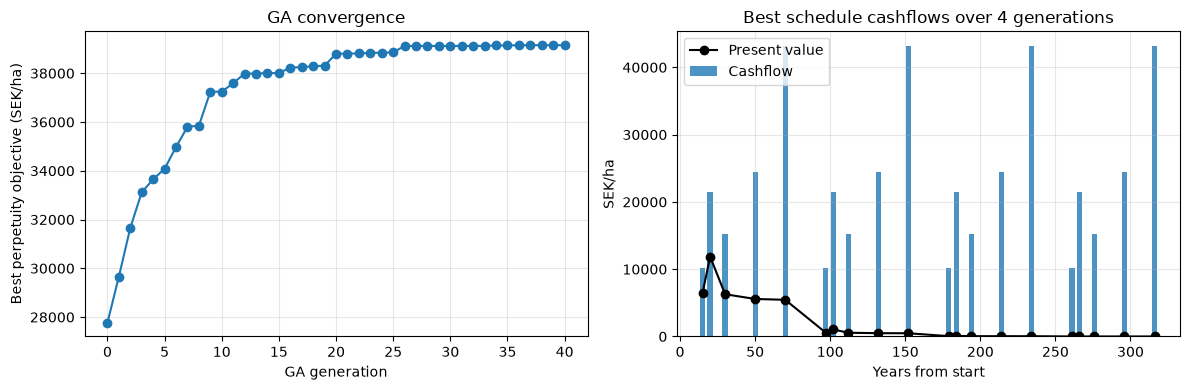

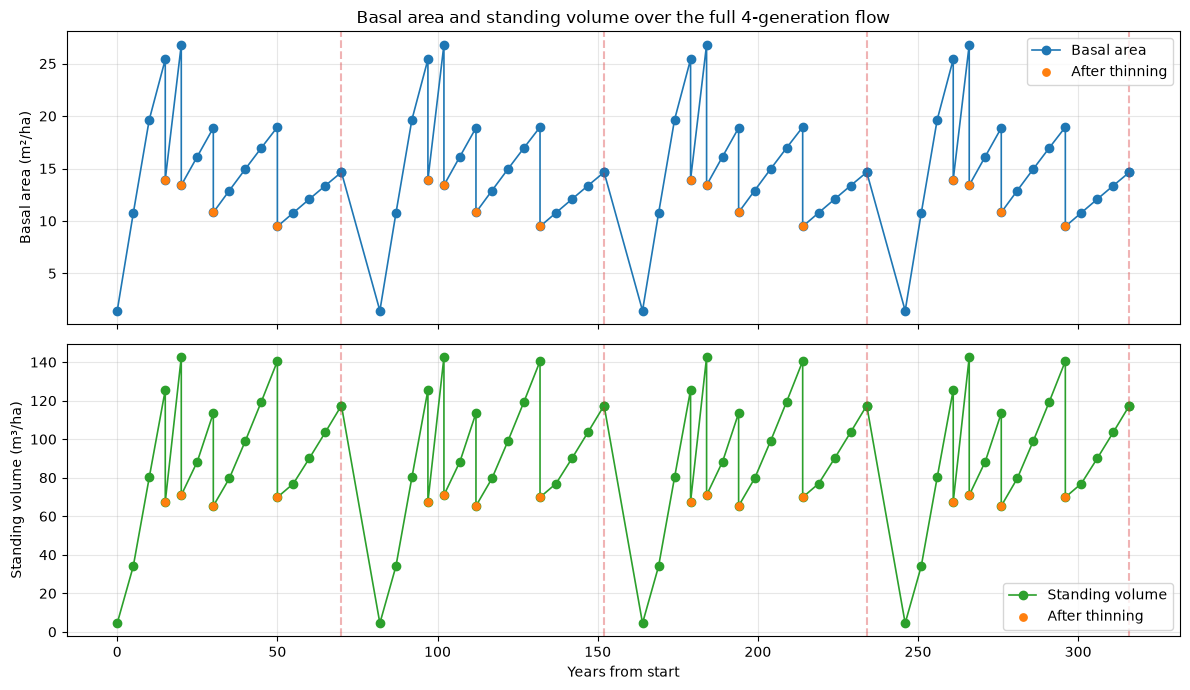

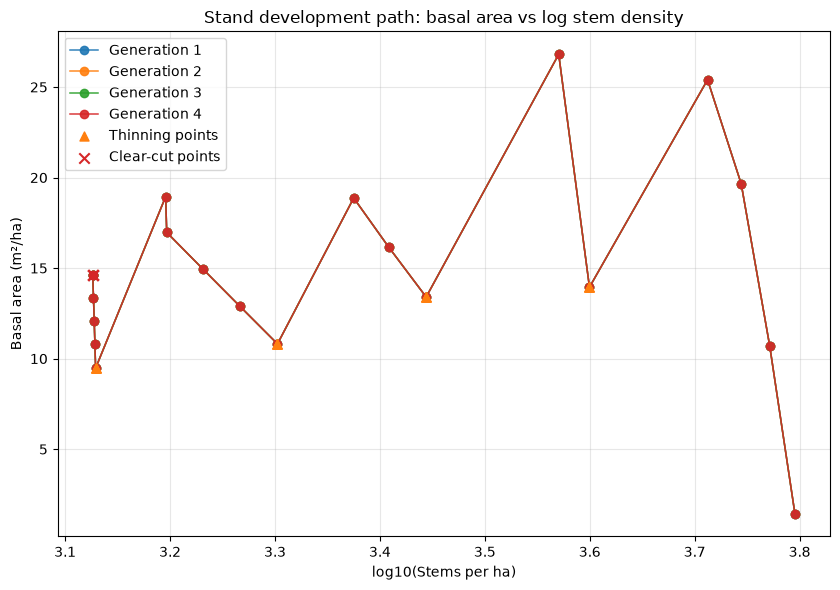

In [8]:
GA_POP_SIZE = 96
GA_GA_GENERATIONS = 40
GA_ELITE = 10
GA_TOURNAMENT_SIZE = 24
GA_MUTATION_RATE = 0.20
GA_CROSSOVER_RATE = 0.80
GA_WORKERS = min(8, max(1, (os.cpu_count() or 2) - 1))

rng = np.random.default_rng(20260218)
population = [ga_random_genome(rng) for _ in range(GA_POP_SIZE)]

best_npv_history: list[float] = []
best_schedule_history: list[tuple[tuple[int, float], ...]] = []

parallel = Parallel(n_jobs=GA_WORKERS, backend="loky") if GA_WORKERS > 1 else None

if parallel is not None:
    context = parallel
else:
    context = None

if context is None:
    fitness, decoded = ga_evaluate_population(
        population,
        config_arg=config,
        site_arg=site,
        parallel=None,
    )

    for ga_generation in range(GA_GA_GENERATIONS + 1):
        best_index = int(np.argmax(fitness))
        best_npv = float(fitness[best_index])
        best_schedule = decoded[best_index]

        best_npv_history.append(best_npv)
        best_schedule_history.append(best_schedule)

        print(
            f"GA generation {ga_generation:02d} | best perpetuity objective: {best_npv:,.0f} SEK/ha "
            f"| schedule: {best_schedule}"
        )

        if ga_generation == GA_GA_GENERATIONS:
            break

        elite_indices = np.argsort(fitness)[-GA_ELITE:]
        next_population = [population[int(i)].copy() for i in elite_indices]

        parents = ga_tournament_select(
            population,
            fitness,
            rng,
            n_select=GA_POP_SIZE - GA_ELITE,
            tournament_size=GA_TOURNAMENT_SIZE,
        )

        for idx in range(0, len(parents), 2):
            parent_a = parents[idx]
            parent_b = parents[(idx + 1) % len(parents)]
            child_a, child_b = ga_crossover(
                parent_a,
                parent_b,
                rng,
                rate=GA_CROSSOVER_RATE,
            )
            next_population.append(ga_mutate(child_a, rng, rate=GA_MUTATION_RATE))
            if len(next_population) < GA_POP_SIZE:
                next_population.append(ga_mutate(child_b, rng, rate=GA_MUTATION_RATE))

        population = next_population[:GA_POP_SIZE]
        fitness, decoded = ga_evaluate_population(
            population,
            config_arg=config,
            site_arg=site,
            parallel=None,
        )
else:
    with context as parallel_runner:
        fitness, decoded = ga_evaluate_population(
            population,
            config_arg=config,
            site_arg=site,
            parallel=parallel_runner,
        )

        for ga_generation in range(GA_GA_GENERATIONS + 1):
            best_index = int(np.argmax(fitness))
            best_npv = float(fitness[best_index])
            best_schedule = decoded[best_index]

            best_npv_history.append(best_npv)
            best_schedule_history.append(best_schedule)

            print(
                f"GA generation {ga_generation:02d} | best perpetuity objective: {best_npv:,.0f} SEK/ha "
                f"| schedule: {best_schedule}"
            )

            if ga_generation == GA_GA_GENERATIONS:
                break

            elite_indices = np.argsort(fitness)[-GA_ELITE:]
            next_population = [population[int(i)].copy() for i in elite_indices]

            parents = ga_tournament_select(
                population,
                fitness,
                rng,
                n_select=GA_POP_SIZE - GA_ELITE,
                tournament_size=GA_TOURNAMENT_SIZE,
            )

            for idx in range(0, len(parents), 2):
                parent_a = parents[idx]
                parent_b = parents[(idx + 1) % len(parents)]
                child_a, child_b = ga_crossover(
                    parent_a,
                    parent_b,
                    rng,
                    rate=GA_CROSSOVER_RATE,
                )
                next_population.append(ga_mutate(child_a, rng, rate=GA_MUTATION_RATE))
                if len(next_population) < GA_POP_SIZE:
                    next_population.append(ga_mutate(child_b, rng, rate=GA_MUTATION_RATE))

            population = next_population[:GA_POP_SIZE]
            fitness, decoded = ga_evaluate_population(
                population,
                config_arg=config,
                site_arg=site,
                parallel=parallel_runner,
            )

best_schedule = best_schedule_history[-1]
best_npv, best_cashflows = ga_simulate_schedule(
    best_schedule,
    config_arg=config,
    site_arg=site,
    return_trace=True,
)

best_routine_df = pd.DataFrame(
    [
        {
            "thinning_no": idx + 1,
            "year_in_rotation": age_year,
            "basal_area_fraction_removed": intensity,
            "thinning_grade": grade,
            "spruce_weight": spruce_weight,
            "pine_weight": pine_weight,
            "broadleaf_weight": broadleaf_weight,
        }
        for idx, (
            age_year,
            intensity,
            grade,
            spruce_weight,
            pine_weight,
            broadleaf_weight,
        ) in enumerate(best_schedule)
    ]
)

print(f"\nBest perpetuity objective over {GA_NUM_GENERATIONS} generations: {best_npv:,.0f} SEK/ha")
print(f"Workers used: {GA_WORKERS}")

if best_routine_df.empty:
    print("Best routine: no thinning before clear-cut.")
else:
    display(best_routine_df)

display(best_cashflows)

best_flow_trajectory = ga_build_flow_trajectory(
    best_schedule,
    config_arg=config,
    site_arg=site,
)

display(best_flow_trajectory)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(len(best_npv_history)), best_npv_history, marker="o")
axes[0].set_xlabel("GA generation")
axes[0].set_ylabel("Best perpetuity objective (SEK/ha)")
axes[0].set_title("GA convergence")
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    best_cashflows["year"],
    best_cashflows["cashflow_sek_per_ha"],
    width=3.5,
    alpha=0.8,
    label="Cashflow",
)
axes[1].plot(
    best_cashflows["year"],
    best_cashflows["pv_sek_per_ha"],
    color="black",
    marker="o",
    label="Present value",
)
axes[1].set_xlabel("Years from start")
axes[1].set_ylabel("SEK/ha")
axes[1].set_title("Best schedule cashflows over 4 generations")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()


flow_plot_df = best_flow_trajectory.sort_values(["year", "event"]).reset_index(drop=True)
clearcut_years = sorted(flow_plot_df.loc[flow_plot_df["event"] == "clearcut", "year"].unique())
thinning_points = flow_plot_df.loc[flow_plot_df["event"] == "thinning"]

fig2, axes2 = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes2[0].plot(
    flow_plot_df["year"],
    flow_plot_df["basal_area_m2_ha"],
    marker="o",
    linewidth=1.2,
    color="tab:blue",
    label="Basal area",
)
if not thinning_points.empty:
    axes2[0].scatter(
        thinning_points["year"],
        thinning_points["basal_area_m2_ha"],
        color="tab:orange",
        s=28,
        label="After thinning",
        zorder=3,
    )
axes2[0].set_ylabel("Basal area (m²/ha)")
axes2[0].set_title("Basal area and standing volume over the full 4-generation flow")
axes2[0].grid(True, alpha=0.3)
axes2[0].legend()

axes2[1].plot(
    flow_plot_df["year"],
    flow_plot_df["standing_volume_m3sk_per_ha"],
    marker="o",
    linewidth=1.2,
    color="tab:green",
    label="Standing volume",
)
if not thinning_points.empty:
    axes2[1].scatter(
        thinning_points["year"],
        thinning_points["standing_volume_m3sk_per_ha"],
        color="tab:orange",
        s=28,
        label="After thinning",
        zorder=3,
    )
axes2[1].set_xlabel("Years from start")
axes2[1].set_ylabel("Standing volume (m³/ha)")
axes2[1].grid(True, alpha=0.3)
axes2[1].legend()

for clearcut_year in clearcut_years:
    for axis in axes2:
        axis.axvline(clearcut_year, color="tab:red", linestyle="--", alpha=0.35)

fig2.tight_layout()


fig3, ax3 = plt.subplots(figsize=(8.5, 6))
flow_phase_df = flow_plot_df.loc[flow_plot_df["stems_per_ha"] > 0.0].copy()
flow_phase_df["log10_stems_per_ha"] = np.log10(flow_phase_df["stems_per_ha"].clip(lower=1e-6))

for generation in sorted(flow_phase_df["generation"].unique()):
    generation_df = flow_phase_df.loc[flow_phase_df["generation"] == generation].copy()
    generation_df = generation_df.sort_values(["year", "event"]) 
    ax3.plot(
        generation_df["log10_stems_per_ha"],
        generation_df["basal_area_m2_ha"],
        marker="o",
        linewidth=1.1,
        label=f"Generation {int(generation)}",
        alpha=0.9,
    )

thinning_phase_df = flow_phase_df.loc[flow_phase_df["event"] == "thinning"]
if not thinning_phase_df.empty:
    ax3.scatter(
        thinning_phase_df["log10_stems_per_ha"],
        thinning_phase_df["basal_area_m2_ha"],
        marker="^",
        s=42,
        color="tab:orange",
        label="Thinning points",
        zorder=3,
    )

clearcut_phase_df = flow_phase_df.loc[flow_phase_df["event"] == "clearcut"]
if not clearcut_phase_df.empty:
    ax3.scatter(
        clearcut_phase_df["log10_stems_per_ha"],
        clearcut_phase_df["basal_area_m2_ha"],
        marker="x",
        s=56,
        color="tab:red",
        label="Clear-cut points",
        zorder=3,
    )

ax3.set_xlabel("log10(Stems per ha)")
ax3.set_ylabel("Basal area (m²/ha)")
ax3.set_title("Stand development path: basal area vs log stem density")
ax3.grid(True, alpha=0.3)
ax3.legend()
fig3.tight_layout()


## Rent and Accounting Method Competitions (1%, 2%, 3%, 4%)

For each rent rate, we run a GA competition under multiple accounting objectives (including Faustmann) and compare the optimized routines.


Best Perpetuity NPV routine per rent rate:


,rent_rate,accounting_method,perpetuity_npv_sek_per_ha,n_thinnings,best_schedule
0,1%,Perpetuity EAV,127784.658014,3,"((15, 0.408, 1.0, 1.43, 1.207, 3.0), (35, 0.29..."
1,2%,Perpetuity NPV,58481.644805,4,"((15, 0.461, 0.093, 2.636, 1.765, 3.0), (20, 0..."
2,3%,Perpetuity NPV,37067.767961,4,"((15, 0.497, 0.765, 1.146, 0.894, 1.545), (20,..."
3,4%,Perpetuity LEV,24983.278885,4,"((15, 0.48, 0.458, 1.931, 0.539, 1.398), (20, ..."


,rent_rate,accounting_method,objective_value,perpetuity_npv_sek_per_ha,perpetuity_eav_sek_per_ha_year,perpetuity_lev_sek_per_ha,n_thinnings,best_schedule
0,1%,Perpetuity EAV,1277.846580,127784.658014,1277.846580,127784.658014,3,"((15, 0.408, 1.0, 1.43, 1.207, 3.0), (35, 0.29..."
1,1%,Perpetuity LEV,126443.372541,126443.372541,1264.433725,126443.372541,4,"((15, 0.392, -0.714, 0.25, 1.004, 2.92), (30, ..."
2,1%,Perpetuity NPV,126736.104879,126736.104879,1267.361049,126736.104879,4,"((15, 0.431, 0.548, 1.3, 0.396, 1.433), (20, 0..."
3,2%,Perpetuity EAV,1139.723607,56986.180336,1139.723607,56986.180336,3,"((15, 0.5, 0.722, 0.823, 1.251, 2.766), (25, 0..."
4,2%,Perpetuity LEV,54418.143071,54418.143071,1088.362861,54418.143071,3,"((15, 0.398, 0.614, 2.524, 0.475, 2.323), (30,..."
5,2%,Perpetuity NPV,58481.644805,58481.644805,1169.632896,58481.644805,4,"((15, 0.461, 0.093, 2.636, 1.765, 3.0), (20, 0..."
6,3%,Perpetuity EAV,1078.367444,35945.581469,1078.367444,35945.581469,4,"((15, 0.456, 0.458, 0.775, 0.972, 2.853), (20,..."
7,3%,Perpetuity LEV,34267.922483,34267.922483,1028.037674,34267.922483,4,"((15, 0.353, 0.328, 1.954, 0.25, 1.939), (20, ..."
8,3%,Perpetuity NPV,37067.767961,37067.767961,1112.033039,37067.767961,4,"((15, 0.497, 0.765, 1.146, 0.894, 1.545), (20,..."
9,4%,Perpetuity EAV,956.412434,23910.310838,956.412434,23910.310838,4,"((15, 0.382, 0.098, 0.866, 1.396, 1.931), (20,..."


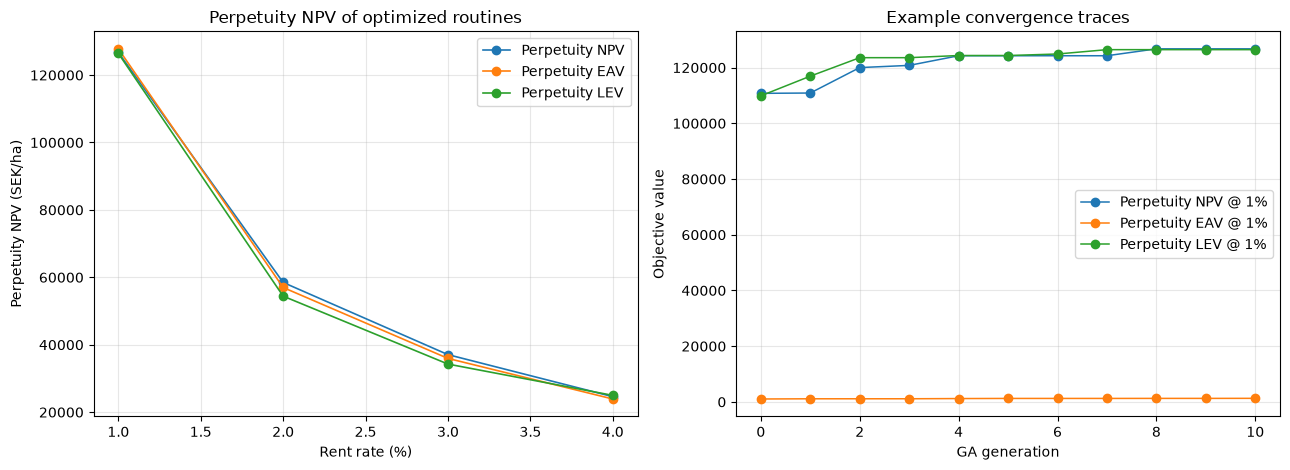

In [9]:
rent_rates = [0.01, 0.02, 0.03, 0.04]
accounting_methods = [
    ("Perpetuity NPV", "perpetuity_npv"),
    ("Perpetuity EAV", "perpetuity_eav"),
    ("Perpetuity LEV", "perpetuity_lev"),
]

# Moderate defaults for multi-scenario runs; increase if you want harder search.
ACC_POP_SIZE = 28
ACC_GA_GENERATIONS = 10
ACC_ELITE = 4
ACC_TOURNAMENT_SIZE = 10
ACC_MUTATION_RATE = 0.20
ACC_CROSSOVER_RATE = 0.80
ACC_WORKERS = min(6, max(1, (os.cpu_count() or 2) - 1))

competition_rows: list[dict[str, object]] = []
competition_histories: dict[tuple[str, float], list[float]] = {}
competition_schedules: dict[tuple[str, float], tuple[tuple[int, float], ...]] = {}

for method_label, method_key in accounting_methods:
    for rate in rent_rates:
        seed = 20260218 + int(round(rate * 1000.0)) + abs(hash(method_key)) % 10000

        result = ga_optimize_routine(
            config_arg=config,
            site_arg=site,
            discount_rate=rate,
            accounting_method=method_key,
            pop_size=ACC_POP_SIZE,
            ga_generations=ACC_GA_GENERATIONS,
            elite=ACC_ELITE,
            tournament_size=ACC_TOURNAMENT_SIZE,
            mutation_rate=ACC_MUTATION_RATE,
            crossover_rate=ACC_CROSSOVER_RATE,
            workers=ACC_WORKERS,
            seed=seed,
            verbose=False,
        )

        metrics = result["best_metrics"]
        best_schedule = result["best_schedule"]

        competition_histories[(method_key, rate)] = [float(v) for v in result["best_score_history"]]
        competition_schedules[(method_key, rate)] = best_schedule

        competition_rows.append(
            {
                "rent_rate": f"{int(rate * 100)}%",
                "rent_rate_value": float(rate),
                "accounting_method": method_label,
                "method_key": method_key,
                "objective_value": float(result["best_objective"]),
                "perpetuity_npv_sek_per_ha": float(metrics["perpetuity_npv_sek_per_ha"]),
                "perpetuity_eav_sek_per_ha_year": float(metrics["perpetuity_eav_sek_per_ha_year"]),
                "perpetuity_lev_sek_per_ha": float(metrics["perpetuity_lev_sek_per_ha"]),
                "perpetuity_annuity_sek_per_ha_year": float(
                    metrics["perpetuity_annuity_sek_per_ha_year"]
                ),
                "best_schedule": str(best_schedule),
                "n_thinnings": int(len(best_schedule)),
            }
        )

competition_df = pd.DataFrame(competition_rows).sort_values(
    ["rent_rate_value", "accounting_method"]
)


best_npv_by_rent_df = competition_df.loc[
    competition_df.groupby("rent_rate_value")["perpetuity_npv_sek_per_ha"].idxmax()
].sort_values("rent_rate_value")

print("Best Perpetuity NPV routine per rent rate:")
display(
    best_npv_by_rent_df[
        [
            "rent_rate",
            "accounting_method",
            "perpetuity_npv_sek_per_ha",
            "n_thinnings",
            "best_schedule",
        ]
    ].reset_index(drop=True)
)

display(
    competition_df[
        [
            "rent_rate",
            "accounting_method",
            "objective_value",
            "perpetuity_npv_sek_per_ha",
            "perpetuity_eav_sek_per_ha_year",
            "perpetuity_lev_sek_per_ha",
            "n_thinnings",
            "best_schedule",
        ]
    ].reset_index(drop=True)
)

# Common metric comparison: resulting perpetuity NPV for each optimized routine.
npv_pivot = competition_df.pivot(
    index="rent_rate",
    columns="accounting_method",
    values="perpetuity_npv_sek_per_ha",
)

fig4, axes4 = plt.subplots(1, 2, figsize=(13, 4.8))

for method_label, _method_key in accounting_methods:
    method_df = competition_df.loc[competition_df["accounting_method"] == method_label]
    axes4[0].plot(
        method_df["rent_rate_value"] * 100.0,
        method_df["perpetuity_npv_sek_per_ha"],
        marker="o",
        linewidth=1.2,
        label=method_label,
    )

axes4[0].set_xlabel("Rent rate (%)")
axes4[0].set_ylabel("Perpetuity NPV (SEK/ha)")
axes4[0].set_title("Perpetuity NPV of optimized routines")
axes4[0].grid(True, alpha=0.3)
axes4[0].legend()

for method_label, method_key in accounting_methods:
    method_subset = competition_df.loc[competition_df["accounting_method"] == method_label]
    best_rate = float(method_subset.loc[method_subset["objective_value"].idxmax(), "rent_rate_value"])
    history = competition_histories[(method_key, best_rate)]
    axes4[1].plot(
        range(len(history)),
        history,
        marker="o",
        linewidth=1.1,
        label=f"{method_label} @ {int(best_rate * 100)}%",
    )

axes4[1].set_xlabel("GA generation")
axes4[1].set_ylabel("Objective value")
axes4[1].set_title("Example convergence traces")
axes4[1].grid(True, alpha=0.3)
axes4[1].legend()

fig4.tight_layout()


## Site Index Spruce Sweep (12 to 36, step 2)

This section re-optimizes the routine for each spruce site index (`SI_spruce = 12, 14, ..., 36`) with the expanded thinning decision:
- thinning age,
- thinning intensity,
- thinning grade (from below to from above),
- species targeting weights (spruce/pine/broadleaf).

It then compares how optimized behavior and value outcomes change as site index increases.


Optimizing for spruce SI=12 ...


Optimizing for spruce SI=14 ...


Optimizing for spruce SI=16 ...


Optimizing for spruce SI=18 ...


Optimizing for spruce SI=20 ...


...

Optimizing for spruce SI=30 ...


Optimizing for spruce SI=32 ...


Optimizing for spruce SI=34 ...


Optimizing for spruce SI=36 ...


,si_spruce_m,best_objective,perpetuity_npv_sek_per_ha,perpetuity_eav_sek_per_ha_year,n_thinnings,first_thinning_year,mean_thinning_intensity,mean_thinning_grade,mean_spruce_weight,mean_pine_weight,mean_broadleaf_weight,removed_spruce_share,removed_pine_share,removed_broadleaf_share,peak_basal_area_m2_ha,peak_standing_volume_m3sk_per_ha,best_schedule
0,12.0,34504.150512,34504.150512,1035.124515,3,15.0,0.428667,0.456667,1.010667,2.142000,2.338000,0.000000,0.598374,0.401626,29.618278,196.202622,"((15, 0.286, 0.289, 2.188, 1.974, 2.631), (20,..."
1,14.0,35572.277918,35572.277918,1067.168338,4,15.0,0.473500,0.503250,1.547000,1.101250,1.569250,0.085731,0.587563,0.326706,26.264207,139.296812,"((15, 0.466, 1.0, 0.25, 0.849, 2.574), (20, 0...."
2,16.0,37014.760247,37014.760247,1110.442807,4,15.0,0.474250,-0.053250,1.611000,2.179000,2.146750,0.094252,0.579070,0.326678,25.701111,169.112533,"((15, 0.493, 0.356, 2.507, 1.954, 2.66), (20, ..."
3,18.0,35692.660329,35692.660329,1070.779810,4,15.0,0.392750,0.044250,2.018500,1.337750,1.195500,0.101561,0.556614,0.341825,29.529564,158.058877,"((15, 0.312, 0.415, 2.575, 0.472, 2.195), (20,..."
4,20.0,34560.831332,34560.831332,1036.824940,4,10.0,0.390250,0.028750,2.416000,1.364500,1.233750,0.103133,0.525735,0.371132,28.555758,183.600323,"((10, 0.171, -0.975, 1.223, 0.709, 1.651), (15..."
5,22.0,35873.381763,35873.381763,1076.201453,4,15.0,0.411000,0.031500,1.467750,1.771000,1.893500,0.091996,0.570499,0.337505,28.849492,169.778256,"((15, 0.5, 0.669, 1.999, 1.636, 2.522), (25, 0..."
6,24.0,33934.342121,33934.342121,1018.030264,3,15.0,0.415667,0.231667,2.066333,1.131667,1.395667,0.110424,0.492867,0.396710,28.111314,224.473850,"((15, 0.362, 0.001, 1.951, 1.808, 3.0), (20, 0..."
7,26.0,32467.482929,32467.482929,974.024488,4,10.0,0.363500,0.027000,1.425750,0.752000,2.628500,0.111524,0.491552,0.396924,29.646615,207.276514,"((10, 0.128, -0.637, 1.027, 1.105, 3.0), (15, ..."
8,28.0,36347.794034,36347.794034,1090.433821,4,15.0,0.397250,0.022750,1.127500,1.511500,1.978250,0.089816,0.567793,0.342391,27.283404,174.845115,"((15, 0.41, 0.979, 0.25, 0.877, 1.146), (20, 0..."
9,30.0,35415.187457,35415.187457,1062.455624,4,15.0,0.500000,0.296000,1.582500,1.380250,1.158500,0.093525,0.583672,0.322803,25.696119,137.404221,"((15, 0.5, 0.029, 1.794, 1.137, 1.34), (20, 0...."


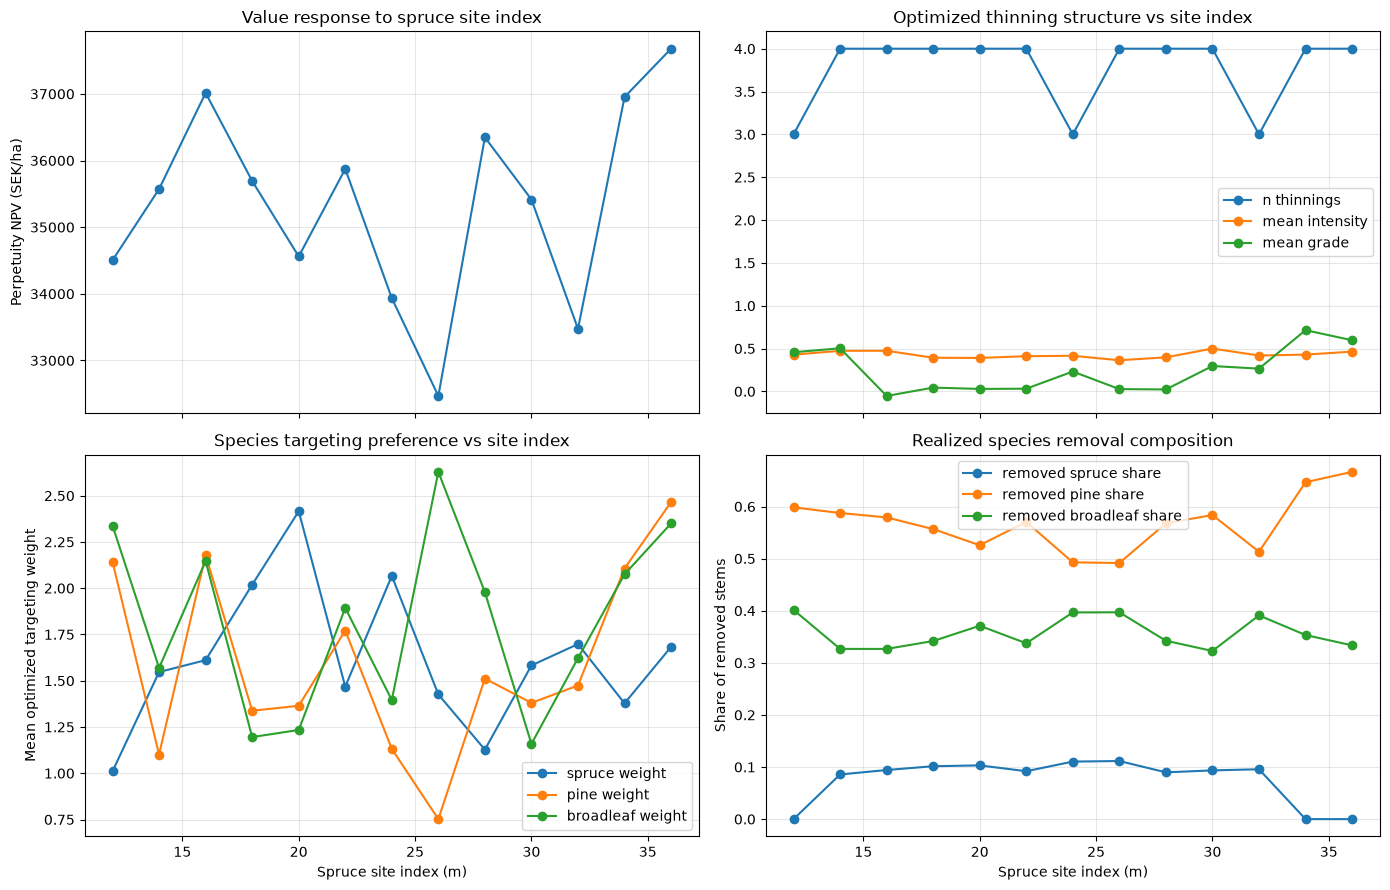

In [10]:
from dataclasses import replace

SI_SWEEP_VALUES = list(range(12, 38, 2))
SI_SWEEP_DISCOUNT_RATE = 0.03
SI_SWEEP_ACCOUNTING_METHOD = "perpetuity_npv"

SI_SWEEP_POP_SIZE = 28
SI_SWEEP_GA_GENERATIONS = 12
SI_SWEEP_ELITE = 4
SI_SWEEP_TOURNAMENT_SIZE = 10
SI_SWEEP_MUTATION_RATE = 0.20
SI_SWEEP_CROSSOVER_RATE = 0.80
SI_SWEEP_WORKERS = min(6, max(1, (os.cpu_count() or 2) - 1))

si_rows: list[dict[str, object]] = []
si_schedule_map: dict[int, tuple[tuple[int, float, float, float, float, float], ...]] = {}

for si_spruce in SI_SWEEP_VALUES:
    print(f"Optimizing for spruce SI={si_spruce} ...")

    config_si = replace(config, site_index_spruce_m=float(si_spruce))
    result_si = ga_optimize_routine(
        config_arg=config_si,
        site_arg=site,
        discount_rate=SI_SWEEP_DISCOUNT_RATE,
        accounting_method=SI_SWEEP_ACCOUNTING_METHOD,
        pop_size=SI_SWEEP_POP_SIZE,
        ga_generations=SI_SWEEP_GA_GENERATIONS,
        elite=SI_SWEEP_ELITE,
        tournament_size=SI_SWEEP_TOURNAMENT_SIZE,
        mutation_rate=SI_SWEEP_MUTATION_RATE,
        crossover_rate=SI_SWEEP_CROSSOVER_RATE,
        workers=SI_SWEEP_WORKERS,
        seed=20260400 + int(si_spruce),
        verbose=False,
    )

    best_schedule_si = result_si["best_schedule"]
    si_schedule_map[int(si_spruce)] = best_schedule_si

    flow_si = ga_build_flow_trajectory(
        best_schedule_si,
        config_arg=config_si,
        site_arg=site,
    )

    thinning_flow_si = flow_si.loc[flow_si["event"] == "thinning"].copy()

    if best_schedule_si:
        intensities = [float(decision[1]) for decision in best_schedule_si]
        grades = [float(decision[2]) for decision in best_schedule_si]
        w_spruce = [float(decision[3]) for decision in best_schedule_si]
        w_pine = [float(decision[4]) for decision in best_schedule_si]
        w_broadleaf = [float(decision[5]) for decision in best_schedule_si]
        first_thinning_year = float(min(decision[0] for decision in best_schedule_si))
    else:
        intensities = []
        grades = []
        w_spruce = []
        w_pine = []
        w_broadleaf = []
        first_thinning_year = np.nan

    removed_spruce = float(thinning_flow_si["removed_spruce_stems_per_ha"].sum())
    removed_pine = float(thinning_flow_si["removed_pine_stems_per_ha"].sum())
    removed_broadleaf = float(thinning_flow_si["removed_broadleaf_stems_per_ha"].sum())
    removed_total = removed_spruce + removed_pine + removed_broadleaf

    si_rows.append(
        {
            "si_spruce_m": float(si_spruce),
            "best_objective": float(result_si["best_objective"]),
            "perpetuity_npv_sek_per_ha": float(result_si["best_metrics"]["perpetuity_npv_sek_per_ha"]),
            "perpetuity_eav_sek_per_ha_year": float(
                result_si["best_metrics"]["perpetuity_eav_sek_per_ha_year"]
            ),
            "n_thinnings": int(len(best_schedule_si)),
            "first_thinning_year": float(first_thinning_year)
            if not np.isnan(first_thinning_year)
            else np.nan,
            "mean_thinning_intensity": float(np.mean(intensities)) if intensities else 0.0,
            "mean_thinning_grade": float(np.mean(grades)) if grades else 0.0,
            "mean_spruce_weight": float(np.mean(w_spruce)) if w_spruce else 0.0,
            "mean_pine_weight": float(np.mean(w_pine)) if w_pine else 0.0,
            "mean_broadleaf_weight": float(np.mean(w_broadleaf)) if w_broadleaf else 0.0,
            "removed_spruce_share": float(removed_spruce / removed_total) if removed_total > 0 else 0.0,
            "removed_pine_share": float(removed_pine / removed_total) if removed_total > 0 else 0.0,
            "removed_broadleaf_share": float(removed_broadleaf / removed_total)
            if removed_total > 0
            else 0.0,
            "peak_basal_area_m2_ha": float(flow_si["basal_area_m2_ha"].max()),
            "peak_standing_volume_m3sk_per_ha": float(flow_si["standing_volume_m3sk_per_ha"].max()),
            "best_schedule": str(best_schedule_si),
        }
    )

si_df = pd.DataFrame(si_rows).sort_values("si_spruce_m").reset_index(drop=True)
display(si_df)

fig_si, axes_si = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

axes_si[0, 0].plot(si_df["si_spruce_m"], si_df["perpetuity_npv_sek_per_ha"], marker="o")
axes_si[0, 0].set_ylabel("Perpetuity NPV (SEK/ha)")
axes_si[0, 0].set_title("Value response to spruce site index")
axes_si[0, 0].grid(True, alpha=0.3)

axes_si[0, 1].plot(si_df["si_spruce_m"], si_df["n_thinnings"], marker="o", label="n thinnings")
axes_si[0, 1].plot(
    si_df["si_spruce_m"],
    si_df["mean_thinning_intensity"],
    marker="o",
    label="mean intensity",
)
axes_si[0, 1].plot(
    si_df["si_spruce_m"],
    si_df["mean_thinning_grade"],
    marker="o",
    label="mean grade",
)
axes_si[0, 1].set_title("Optimized thinning structure vs site index")
axes_si[0, 1].grid(True, alpha=0.3)
axes_si[0, 1].legend()

axes_si[1, 0].plot(si_df["si_spruce_m"], si_df["mean_spruce_weight"], marker="o", label="spruce weight")
axes_si[1, 0].plot(si_df["si_spruce_m"], si_df["mean_pine_weight"], marker="o", label="pine weight")
axes_si[1, 0].plot(
    si_df["si_spruce_m"],
    si_df["mean_broadleaf_weight"],
    marker="o",
    label="broadleaf weight",
)
axes_si[1, 0].set_xlabel("Spruce site index (m)")
axes_si[1, 0].set_ylabel("Mean optimized targeting weight")
axes_si[1, 0].set_title("Species targeting preference vs site index")
axes_si[1, 0].grid(True, alpha=0.3)
axes_si[1, 0].legend()

axes_si[1, 1].plot(
    si_df["si_spruce_m"],
    si_df["removed_spruce_share"],
    marker="o",
    label="removed spruce share",
)
axes_si[1, 1].plot(
    si_df["si_spruce_m"],
    si_df["removed_pine_share"],
    marker="o",
    label="removed pine share",
)
axes_si[1, 1].plot(
    si_df["si_spruce_m"],
    si_df["removed_broadleaf_share"],
    marker="o",
    label="removed broadleaf share",
)
axes_si[1, 1].set_xlabel("Spruce site index (m)")
axes_si[1, 1].set_ylabel("Share of removed stems")
axes_si[1, 1].set_title("Realized species removal composition")
axes_si[1, 1].grid(True, alpha=0.3)
axes_si[1, 1].legend()

fig_si.tight_layout()
